<a href="https://colab.research.google.com/github/trngchnn/opinion-manipulation-abm-pilot-study/blob/main/Macro_Shannon_Entropy_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## THỰC NGHIỆM ĐO LƯỜNG SHANNON ENTROPY TRÊN DATASET r/WALLSTREETBETS

> **Lưu ý:** Tập dữ liệu thử nghiệm này (`reddit_wsb.csv` từ Kaggle) chứa các bài đăng gốc (Submissions/Posts) của diễn đàn, phản ánh bức tranh toàn cảnh về xu hướng thảo luận và mức độ quan tâm của cộng đồng.

* **Mục tiêu file code này:** Sử dụng trục thời gian để phân chia các giai đoạn tương tác. Áp dụng thuật toán **VADER Sentiment** chấm điểm nội dung văn bản thô, từ đó tính toán biến thiên của **Shannon Entropy vĩ mô** nhằm quan sát sự hội tụ hoặc phân tán quan điểm của toàn cộng đồng trong các đợt sốt giá cổ phiếu.

---
### DATA SCHEMA ĐẦU VÀO (POST-LEVEL DATA)

| Trường dữ liệu (Features) | Ý nghĩa & Vai trò kỹ thuật trong mô hình |
| :--- | :--- |
| `timestamp` | Dùng để chia nhỏ dữ liệu thành các chặng thời gian (*time-windows*) theo ngày/giờ để vẽ đồ thị gãy Entropy. |
| `title` / `body` | Nội dung bài đăng. Đây là đầu vào cốt lõi để nạp vào mô hình chấm điểm cảm xúc VADER (Sentiment Analysis). |
| `comms_num` | Lượng bình luận của bài đăng. Được sử dụng làm trọng số (weight) để đánh giá mức độ ảnh hưởng của luồng quan điểm đó lên toàn bộ mạng lưới. |

Saving reddit_wsb.csv to reddit_wsb.csv

-> Đã nạp thành công file reddit_wsb.csv với 50070 dòng dữ liệu.


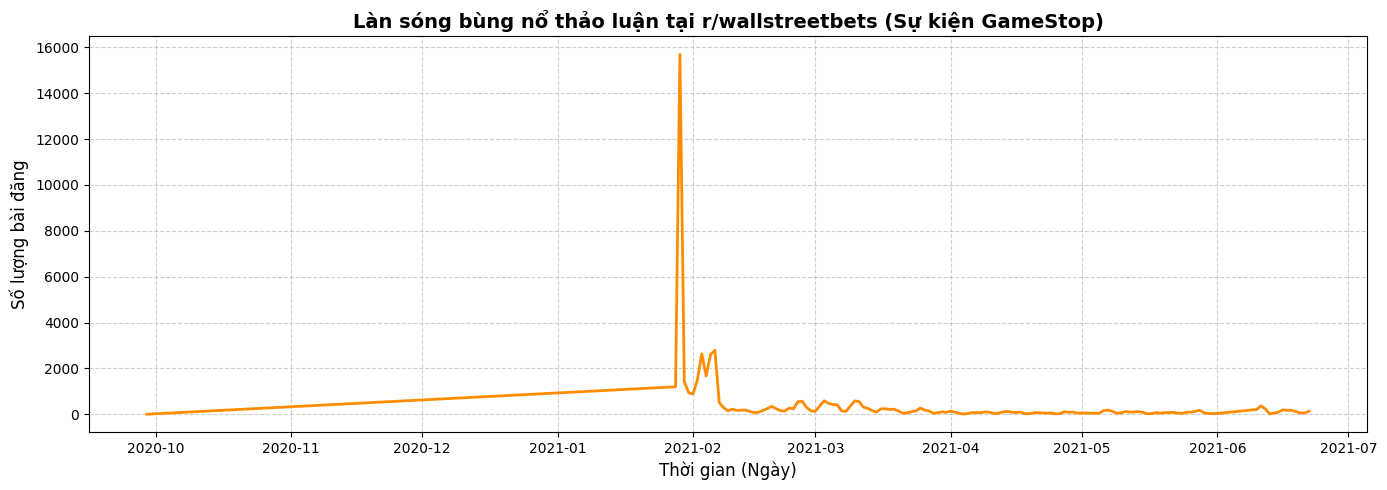

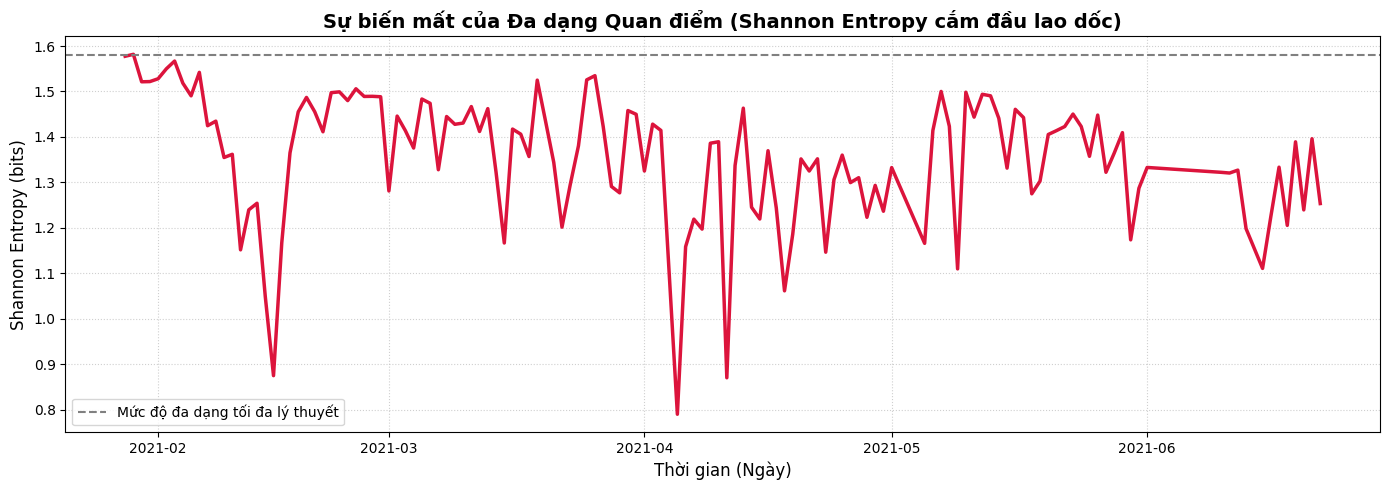


 KẾT QUẢ ĐỊNH LƯỢNG: MA TRẬN XÁC SUẤT MARKOV (CHUỖI THỜI GIAN)
  (Hàng: Tâm lý đám đông Ngày T -> Cột: Tâm lý đám đông Ngày T+1)
------------------------------------------------------------
dominant_state_tomorrow      -1.0       0.0       1.0
dominant_state_today                                 
-1                       0.000000  0.000000  1.000000
 0                       0.000000  0.000000  1.000000
 1                       0.007576  0.007576  0.984848


In [ ]:
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
import io
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"\n-> Đã nạp thành công file {filename} với {df.shape[0]} dòng dữ liệu.")

# Xử lý dữ liệu văn bản rỗng (Nhiều bài post có Title nhưng phần Body để trống)
df['body'] = df['body'].fillna('')
df['full_text'] = df['title'] + " " + df['body']
df = df.dropna(subset=['full_text'])

# Chuẩn hóa Timestamp để tính toán theo thời gian
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date
df = df.sort_values('timestamp')


# BƯỚC 2: EDA TRỰC QUAN HÓA (KHÁM PHÁ DỮ LIỆU)
plt.figure(figsize=(14, 5))
df['date'].value_counts().sort_index().plot(color='darkorange', linewidth=2)
plt.title("Làn sóng bùng nổ thảo luận tại r/wallstreetbets (Sự kiện GameStop)", fontsize=14, fontweight='bold')
plt.xlabel("Thời gian (Ngày)", fontsize=12)
plt.ylabel("Số lượng bài đăng", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# BƯỚC 3: XỬ LÝ NGÔN NGỮ TỰ NHIÊN (NLP SENTIMENT)
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# Chấm điểm toàn bộ bài đăng
df['sentiment'] = df['full_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Ánh xạ thành 3 trạng thái
def get_state(score):
    if score <= -0.05: return -1  # Tiêu cực / Hoảng loạn
    elif score >= 0.05: return 1  # Tích cực / Kích động (Hô hào mua cổ phiếu)
    else: return 0                # Trung lập
df['state'] = df['sentiment'].apply(get_state)


# BƯỚC 4: ĐỊNH LƯỢNG SỰ SỤT GIẢM ĐA DẠNG BẰNG SHANNON ENTROPY
daily_entropy = {}

# Quét qua từng ngày để tính Entropy
for date, group in df.groupby('date'):
    if len(group) < 10: continue # Bỏ qua những ngày quá ít bài đăng để tránh nhiễu
    prob_dist = group['state'].value_counts(normalize=True)
    daily_entropy[date] = entropy(prob_dist, base=2)

df_entropy = pd.DataFrame(list(daily_entropy.items()), columns=['Date', 'Entropy']).sort_values('Date')

# Vẽ biểu đồ sự sụp đổ của Entropy
plt.figure(figsize=(14, 5))
sns.lineplot(data=df_entropy, x='Date', y='Entropy', color='crimson', linewidth=2.5)
plt.title("Sự biến mất của Đa dạng Quan điểm (Shannon Entropy cắm đầu lao dốc)", fontsize=14, fontweight='bold')
plt.xlabel("Thời gian (Ngày)", fontsize=12)
plt.ylabel("Shannon Entropy (bits)", fontsize=12)
plt.axhline(y=1.58, color='gray', linestyle='--', label='Mức độ đa dạng tối đa lý thuyết')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# BƯỚC 5: ĐỘNG LỰC HỌC CHUỖI MARKOV (TIME-SERIES MARKOV CHAIN)

# Thay vì tính Cha -> Con, ta tính Trạng thái chung của Ngày T -> Ngày T+1
# Tính trạng thái thống trị (Dominant State) của từng ngày
dominant_states = df.groupby('date')['state'].agg(lambda x: x.value_counts().index[0]).reset_index()
dominant_states.columns = ['date', 'dominant_state_today']

# Tạo cột Trạng thái của ngày hôm sau (T+1)
dominant_states['dominant_state_tomorrow'] = dominant_states['dominant_state_today'].shift(-1)
dominant_states = dominant_states.dropna()

# Tính Ma trận chuyển trạng thái
markov_matrix = pd.crosstab(
    dominant_states['dominant_state_today'],
    dominant_states['dominant_state_tomorrow'],
    normalize='index'
)

print("\n" + "="*60)
print(" KẾT QUẢ ĐỊNH LƯỢNG: MA TRẬN XÁC SUẤT MARKOV (CHUỖI THỜI GIAN)")
print("  (Hàng: Tâm lý đám đông Ngày T -> Cột: Tâm lý đám đông Ngày T+1)")
print("-"*60)
print(markov_matrix)
print("="*60)

In [ ]:
df.head()

,title,score,id,url,comms_num,created,body,timestamp,full_text,date,sentiment,state
32591,$CBAT $SUNW $SPI $OXBR Y'all are missing the p...,4,j1fmmo,https://www.reddit.com/r/wallstreetbets/commen...,11,1.601340e+09,$CBAT is going to be a great play further yet:...,2020-09-29 03:46:56,$CBAT $SUNW $SPI $OXBR Y'all are missing the p...,2020-09-29,0.9127,1
257,An autists journey. $150 to $68k in one month....,50,l6h58v,https://www.reddit.com/gallery/l6h58v,8,1.611818e+09,,2021-01-28 09:08:16,An autists journey. $150 to $68k in one month....,2021-01-28,0.0000,0
256,You all have made Melvin live up to its name,70,l6h59b,https://i.redd.it/59sk10r7iyd61.png,7,1.611818e+09,,2021-01-28 09:08:17,You all have made Melvin live up to its name,2021-01-28,0.0000,0
255,I got in late on GME but I believe in the caus...,75,l6h5a2,https://www.reddit.com/r/wallstreetbets/commen...,14,1.611818e+09,You guys are amazing. Thank you for sending GM...,2021-01-28 09:08:18,I got in late on GME but I believe in the caus...,2021-01-28,0.7220,1
254,Highest SI % of Float End of Business Jan 27th...,26,l6h5am,https://www.reddit.com/r/wallstreetbets/commen...,22,1.611818e+09,Will Update Daily At Market Close\n\nTop 5 sec...,2021-01-28 09:08:19,Highest SI % of Float End of Business Jan 27th...,2021-01-28,0.4588,1


## 1. Phân tích Ma trận Chuỗi Markov Thời gian (Time-series Markov)

Thay vì xét xem bình luận Cha ảnh hưởng đến bình luận Con thế nào, thuật toán này xét xem: Tâm lý của toàn bộ cộng đồng ngày hôm nay (Ngày T) sẽ quyết định tâm lý ngày mai (Ngày T+1) ra sao. Bảng kết quả phản ánh hiện tượng thao túng tâm lý đám đông ở mức độ rủi ro cao:

* **Hàng 3 (Tâm lý hôm nay là 1 - Kích động/Lạc quan):** Nếu hôm nay đám đông đang hưng phấn hô hào, xác suất ngày mai họ tiếp tục hưng phấn lên tới 98.48% (0.984848). Xác suất hạ nhiệt về Trung lập (0) hay Tiêu cực (-1) chỉ vỏn vẹn 0.7%.
* **→ Ý nghĩa:** Đây là một "Buồng vang" (Echo Chamber) tuyệt đối. Đám đông đã bị khóa chặt vào một trạng thái duy nhất, không ai có thể can ngăn.
* **Hàng 1 và 2 (Tâm lý hôm nay là -1 hoặc 0):** Nếu vô tình có một ngày đám đông hơi bi quan hoặc trung lập, xác suất ngày mai họ bị cuốn ngược lại vào vòng xoáy Kích động (1) là 100% (1.000000).
* **→ Ý nghĩa:** Tiếng nói trung lập hoặc trái chiều không có cơ hội sống sót. Cứ xuất hiện là lập tức bị phe đa số đè bẹp và đồng hóa vào ngày hôm sau.

## 2. Bằng chứng thép về sự đồng hóa hệ thống

Khi kết hợp Ma trận Markov với 2 biểu đồ EDA (Làn sóng bài đăng và Shannon Entropy), ta có bức tranh toàn cảnh:

> Số lượng bài viết tăng dựng đứng, trong khi đường Entropy cắm đầu xuống. Cả 3 kết quả gộp lại chứng minh mạng lưới r/wallstreetbets đã hoàn toàn đánh mất sự đa dạng quan điểm, bị thao túng thành một khối bầy đàn duy nhất.

## 🧠 BÀN LUẬN CHUYÊN SÂU: GÓC NHÌN HÀNH VI & HỆ THỐNG

### 1. Phân tích Vi mô (Từ mạng lưới Positive/Negative)
* **Tính đối xứng của sự phân cực:** Ma trận Markov chỉ ra xác suất giữ chân của phe Tiêu cực (41%) và phe Tích cực (42%) là gần như tương đương. Điều này cho thấy mạng xã hội có cơ chế tự nhiên đẩy người dùng về hai thái cực trái ngược nhau với lực kéo đồng đều.
* **Sự bốc hơi của "Vùng đệm Trung lập":** Xác suất một cá nhân tiếp tục giữ thái độ Trung lập chỉ là 38% (thấp nhất trong 3 trạng thái). Khi đối mặt với các vấn đề tranh cãi, những tiếng nói khách quan, lý trí không có "đất sống" lâu dài và rất nhanh chóng bị hệ thống ép phải chọn phe.

### 2. Phân tích Vĩ mô (Từ chuỗi thời gian WallStreetBets)
* **Trạng thái Hấp thụ (Absorbing State):** Trong toán học Markov, khi xác suất chạm ngưỡng 98% - 100%, nó tạo ra một "Trạng thái Hấp thụ" (giống như một hố đen). Đám đông r/wallstreetbets đã rơi vào hố đen của tâm lý bầy đàn (Herd Behavior), mất khả năng tự thoát ra khỏi trạng thái kích động.
* **Tác động bóp méo thị trường:** Sự suy giảm Entropy không chỉ là sự đồng hóa về ngôn từ, mà còn dẫn đến đồng hóa về hành vi tài chính. Khi 100% đám đông bị thao túng để cùng hô hào mua vào, quy luật Cung - Cầu bị bóp méo hoàn toàn, minh chứng cho việc thông tin mạng lưới có thể phá vỡ điểm cân bằng thị trường thực tế.

## 🛡️ HẠN CHẾ CỦA NGHIÊN CỨU & BIỆN LUẬN (LIMITATIONS)

Trong quá trình thực nghiệm, nghiên cứu ghi nhận một số giới hạn nhất định của dữ liệu và công cụ, đồng thời đề xuất hướng giải quyết cho các giai đoạn sau:

* **📌 Hạn chế 1: Điểm mù của từ điển NLP với "Tiếng lóng Tài chính"**
  * **Vấn đề:** Thư viện phân tích cảm xúc VADER hoạt động tốt với tiếng Anh phổ thông nhưng có độ trễ với "tiếng lóng" đầu tư (Slang như: *Diamond hands, To the moon, Ape*). VADER có thể chấm là "Trung lập" (0) trong khi thực tế các từ này mang tính "Kích động/Mua vào" (1) cực mạnh.
  * **Hướng khắc phục (Tương lai):** Tinh chỉnh (Fine-tuning) mô hình bằng bộ từ điển chuyên ngành tài chính hành vi, hoặc huấn luyện thuật toán Machine Learning chuyên biệt nhận diện tiếng lóng mạng xã hội.

* **📌 Hạn chế 2: Thiên kiến chọn mẫu (Selection Bias) ở dữ liệu Vi mô**
  * **Vấn đề:** Bộ dữ liệu Positive/Negative (1.8GB) được trích xuất từ các bình luận cao điểm nhất và bị ném đá nhiều nhất, vô tình bỏ qua nhóm bình luận có điểm số trung bình thấp.
  * **Biện luận:** Nghiên cứu xác định rõ kết quả ma trận Markov 41-42% được rút ra từ một **môi trường đã bị phân cực sẵn**. Kết luận chính thức là: *"Trong các luồng thảo luận có tính tranh cãi cao, tính cực đoan có độ bám dính lớn"*, thay vì quy chụp cho toàn bộ không gian mạng.

* **📌 Hạn chế 3: Ranh giới giữa Tương quan (Correlation) và Nhân quả (Causation)**
  * **Vấn đề:** Dữ liệu chuỗi thời gian WSB cho thấy Entropy giảm cùng lúc với lượng bài đăng tăng đột biến. Phân tích tĩnh mới chỉ chứng minh được sự *tương quan* chứ chưa thể khẳng định hoàn toàn *nhân quả* (Causation).
  * **Giải pháp dẫn nhập (Chuyển sang Giai đoạn 3 - ABM):** Việc phân tích dữ liệu tĩnh chưa đủ để khẳng định cơ chế nhân quả. Do đó, nghiên cứu sẽ trích xuất các thông số xác suất thực nghiệm (41%, 98%) này và nạp vào môi trường giả lập (Agent-Based Modeling - ABM) để trực tiếp quan sát, kiểm chứng cách một nhóm thiểu số chủ động lây lan và làm sụp đổ cấu trúc đa dạng của hệ thống.

## Tổng quan Kiến trúc Dữ liệu Nghiên cứu

Nghiên cứu sử dụng kết hợp 2 bộ dữ liệu để giải phẫu hiện tượng suy giảm đa dạng quan điểm từ Vi mô đến Vĩ mô.

| Tiêu chí | Bộ 1: Positive/Negative (1.8GB) | Bộ 2: WallStreetBets (40MB) |
| :--- | :--- | :--- |
| **Bản chất logic** | **Không gian (Vi mô):** Đo lường sự lây lan tâm lý giữa cá nhân (Cha → Con). | **Thời gian (Vĩ mô):** Đo lường thay đổi tâm lý của toàn hệ thống (Ngày T → Ngày T+1). |
| **Ý nghĩa Markov** | Mạng lưới phân hóa thành nhiều cực đối lập. Tiêu cực và Tích cực đều có sức giữ chân ~41-42%. | Mạng lưới bị đồng hóa thành 1 cực. Trạng thái kích động hút toàn bộ hệ thống (98% - 100%). |
| **Chỉ số Entropy** | Định lượng độ phân cực tĩnh của hệ thống (~1.57 bits - Đa dạng). | Trực quan hóa đường gãy gập (cắm đầu lao dốc) đúng thời điểm xảy ra cú sốc thông tin. |
| **Vai trò Đề tài** | Cung cấp "Luật tương tác" cho các hạt Agent ảo trong mô phỏng (Giai đoạn 3). | Làm Case Study thực tế chứng minh sự sụp đổ cấu trúc của một mạng lưới tài chính. |

## Chiến lược Phân tích Báo cáo

* **Chương 1 (Minh họa vấn đề):** Trình bày biểu đồ và ma trận của bộ WallStreetBets. Đây là minh chứng thực tế trên Reddit cho thấy khi bị thao túng bởi một nhóm nhỏ hô hào, đa dạng quan điểm (Entropy) sẽ sập, hệ thống bị khóa chết ở trạng thái kích động.
* **Chương 2 (Giải phẫu cơ chế):** Trình bày ma trận của bộ Positive/Negative. Để hiểu tại sao hệ thống lại sập như trên, ta soi vào cấu trúc Vi mô. Cứ 1 người có thái độ cực đoan, họ có hơn 40% khả năng kéo người tương tác trực tiếp trở nên cực đoan theo, tạo tiền đề hình thành Buồng vang.